# House Prediction System

### Importing Required Packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('house_data.csv')
df.shape

(1460, 81)

## Checking data types of the columns

In [152]:
for c in df.columns:
    print(f"{c} | {df[c].dtype}")

MSZoning | int64
LotFrontage | float64
LotArea | int64
LotShape | int64
LandContour | int64
BldgType | int64
HouseStyle | int64
OverallQual | int64
YearBuilt | int64
YearRemodAdd | int64
RoofStyle | int64
RoofMatl | int64
Exterior1st | int64
Exterior2nd | int64
ExterQual | int64
ExterCond | int64
Foundation | int64
BsmtQual | int64
BsmtCond | int64
BsmtExposure | int64
BsmtFinType1 | int64
BsmtFinSF1 | float64
BsmtUnfSF | float64
TotalBsmtSF | int64
HeatingQC | int64
CentralAir | int64
Electrical | int64
1stFlrSF | int64
GrLivArea | int64
FullBath | float64
BedroomAbvGr | float64
KitchenAbvGr | int64
KitchenQual | int64
TotRmsAbvGrd | int64
Functional | int64
Fireplaces | float64
GarageType | int64
GarageYrBlt | float64
GarageFinish | int64
GarageCars | int64
GarageArea | int64
GarageQual | int64
GarageCond | int64
PavedDrive | int64
SaleCondition | int64
SalePrice | int64


# Removing null values form the data set

## Object columns

In [4]:
threshold = len(df)*0.50
total = len(df)
fifty_percent = total - threshold
for c in df.columns:
    if (df[c].dtype == 'object') and ((df[c].isna().sum()) > fifty_percent):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")
        df = df.drop(c, axis = 1)

Column:Alley | Null values:1369
Column:MasVnrType | Null values:872
Column:PoolQC | Null values:1453
Column:Fence | Null values:1179
Column:MiscFeature | Null values:1406


In [5]:
df.shape

(1460, 76)

## Int columns

In [6]:
threshold = len(df)*0.50
total = len(df)
fifty_percent = total - threshold
for c in df.columns:
    if (df[c].dtype == 'int64') and ((df[c].isna().sum()) > fifty_percent):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")
        df = df.drop(c, axis = 1)

In [7]:
df.shape

(1460, 76)

## Float columns

In [8]:
threshold = len(df)*0.50
total = len(df)
fifty_percent = total - threshold
for c in df.columns:
    if (df[c].dtype == 'float64') and ((df[c].isna().sum()) > fifty_percent):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")
        df = df.drop(c, axis = 1)

# 

In [9]:
for c in df.columns:
    if (df[c].dtype == 'object'):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")

Column:MSZoning | Null values:0
Column:Street | Null values:0
Column:LotShape | Null values:0
Column:LandContour | Null values:0
Column:Utilities | Null values:0
Column:LotConfig | Null values:0
Column:LandSlope | Null values:0
Column:Neighborhood | Null values:0
Column:Condition1 | Null values:0
Column:Condition2 | Null values:0
Column:BldgType | Null values:0
Column:HouseStyle | Null values:0
Column:RoofStyle | Null values:0
Column:RoofMatl | Null values:0
Column:Exterior1st | Null values:0
Column:Exterior2nd | Null values:0
Column:ExterQual | Null values:0
Column:ExterCond | Null values:0
Column:Foundation | Null values:0
Column:BsmtQual | Null values:37
Column:BsmtCond | Null values:37
Column:BsmtExposure | Null values:38
Column:BsmtFinType1 | Null values:37
Column:BsmtFinType2 | Null values:38
Column:Heating | Null values:0
Column:HeatingQC | Null values:0
Column:CentralAir | Null values:0
Column:Electrical | Null values:1
Column:KitchenQual | Null values:0
Column:Functional | Nul

In [10]:
df = df.drop(['FireplaceQu'], axis = 1)

In [11]:
for c in df.columns:
    if (df[c].dtype == 'object') and (((df[c].isna()).sum()) != 0):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")
        df = df.dropna(subset = c, axis = 0)


Column:BsmtQual | Null values:37
Column:BsmtExposure | Null values:1
Column:BsmtFinType2 | Null values:1
Column:Electrical | Null values:1
Column:GarageType | Null values:74


In [12]:
df.shape

(1346, 75)

In [13]:
for c in df.columns:
    if (df[c].dtype == 'int64') and (df[c].isna().sum() != 0 ):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")

In [14]:
for c in df.columns:
    if (df[c].dtype == 'float64') and (df[c].isna().sum() != 0 ):
        print(f"Column:{c} | Null values:{df[c].isna().sum()}")

Column:LotFrontage | Null values:246
Column:MasVnrArea | Null values:8


In [15]:
for c in df.columns:
    if (df[c].dtype == 'float64') and (df[c].isna().sum() != 0 ):
        print(f"Column Updated:{c}")
        df[c] = df[c].fillna(df[c].mean())

Column Updated:LotFrontage
Column Updated:MasVnrArea


In [16]:
df.isna().sum().sum()

np.int64(0)

# Removing Zeros From The Data set

## Object columns

In [93]:
for c in df.columns:
    if(df[c].dtype == 'object') and (((df[c] == 0).sum()) != 0):
        print(c)

## int Columns

In [18]:
for c in df.columns:
    if(df[c].dtype == 'int64') and (((df[c] == 0).sum()) != 0):
        print(f"Column: {c} | No. of Zeros {((df[c] == 0 ).sum())}")

Column: BsmtFinSF1 | No. of Zeros 394
Column: BsmtFinSF2 | No. of Zeros 1184
Column: BsmtUnfSF | No. of Zeros 73
Column: 2ndFlrSF | No. of Zeros 753
Column: LowQualFinSF | No. of Zeros 1328
Column: BsmtFullBath | No. of Zeros 766
Column: BsmtHalfBath | No. of Zeros 1266
Column: FullBath | No. of Zeros 8
Column: HalfBath | No. of Zeros 811
Column: BedroomAbvGr | No. of Zeros 6
Column: Fireplaces | No. of Zeros 595
Column: WoodDeckSF | No. of Zeros 675
Column: OpenPorchSF | No. of Zeros 575
Column: EnclosedPorch | No. of Zeros 1162
Column: 3SsnPorch | No. of Zeros 1323
Column: ScreenPorch | No. of Zeros 1230
Column: PoolArea | No. of Zeros 1339
Column: MiscVal | No. of Zeros 1299


In [19]:
threshold = len(df)*0.50
total = len(df)
fifty_percent = total - threshold
for c in df.columns:
    if(df[c].dtype == 'int64') and (((df[c] == 0).sum())  > fifty_percent):
        print(f"Column deleted: {c} | Had Zeros {((df[c] == 0 ).sum())}")
        df = df.drop(c, axis = 1)

Column deleted: BsmtFinSF2 | Had Zeros 1184
Column deleted: 2ndFlrSF | Had Zeros 753
Column deleted: LowQualFinSF | Had Zeros 1328
Column deleted: BsmtFullBath | Had Zeros 766
Column deleted: BsmtHalfBath | Had Zeros 1266
Column deleted: HalfBath | Had Zeros 811
Column deleted: WoodDeckSF | Had Zeros 675
Column deleted: EnclosedPorch | Had Zeros 1162
Column deleted: 3SsnPorch | Had Zeros 1323
Column deleted: ScreenPorch | Had Zeros 1230
Column deleted: PoolArea | Had Zeros 1339
Column deleted: MiscVal | Had Zeros 1299


In [20]:
threshold = len(df)*0.50
total = len(df)
fifty_percent = total - threshold
for c in df.columns:
    if(df[c].dtype == 'float64') and (((df[c] == 0).sum())  > fifty_percent):
        print(f"Column deleted: {c} | Had Zeros {((df[c] == 0 ).sum())}")
        df = df.drop(c, axis = 1)

Column deleted: MasVnrArea | Had Zeros 760


In [21]:
for c in df.columns:
    if(((df[c] == 0).sum())  != 0):
        print(f"Columns: {c} |  Zeros: {((df[c] == 0 ).sum())} Data Type: {df[c].dtype}")

Columns: BsmtFinSF1 |  Zeros: 394 Data Type: int64
Columns: BsmtUnfSF |  Zeros: 73 Data Type: int64
Columns: FullBath |  Zeros: 8 Data Type: int64
Columns: BedroomAbvGr |  Zeros: 6 Data Type: int64
Columns: Fireplaces |  Zeros: 595 Data Type: int64
Columns: OpenPorchSF |  Zeros: 575 Data Type: int64


In [22]:
for c in df.columns:
    if(((df[c] == 0).sum())  != 0):
        print(f"Column: {c} |  Zeros replaced: {((df[c] == 0 ).sum())}")
        df[c] = df[c].replace(0, df[c].mean())
        

Column: BsmtFinSF1 |  Zeros replaced: 394
Column: BsmtUnfSF |  Zeros replaced: 73
Column: FullBath |  Zeros replaced: 8
Column: BedroomAbvGr |  Zeros replaced: 6
Column: Fireplaces |  Zeros replaced: 595
Column: OpenPorchSF |  Zeros replaced: 575


In [23]:
df.shape

(1346, 62)

## Transforming categorical columns into numerical columns

In [24]:
le = LabelEncoder()
for c in df.columns:
    if(df[c].dtype == 'object'):
        df[c] = le.fit_transform(df[c])

In [25]:
for c in df.columns:
    print(df[c].value_counts())

Id
1460    1
1       1
1441    1
1440    1
1439    1
       ..
7       1
6       1
5       1
4       1
3       1
Name: count, Length: 1346, dtype: int64
MSSubClass
20     506
60     297
50     129
120     87
160     61
80      57
70      57
30      51
90      28
190     21
85      19
75      14
45       9
180      6
40       4
Name: count, dtype: int64
MSZoning
3    1071
4     191
1      65
2      11
0       8
Name: count, dtype: int64
LotFrontage
70.777273     246
60.000000     120
80.000000      67
70.000000      63
75.000000      51
             ... 
149.000000      1
182.000000      1
160.000000      1
152.000000      1
46.000000       1
Name: count, Length: 108, dtype: int64
LotArea
9600     23
7200     20
6000     16
8400     13
9000     12
         ..
19690     1
16381     1
9204      1
16545     1
3635      1
Name: count, Length: 1006, dtype: int64
Street
1    1341
0       5
Name: count, dtype: int64
LotShape
3    835
0    461
1     40
2     10
Name: count, dtype: int64
LandCon

# Correlation

In [26]:
correlation = df.corr()

<Axes: >

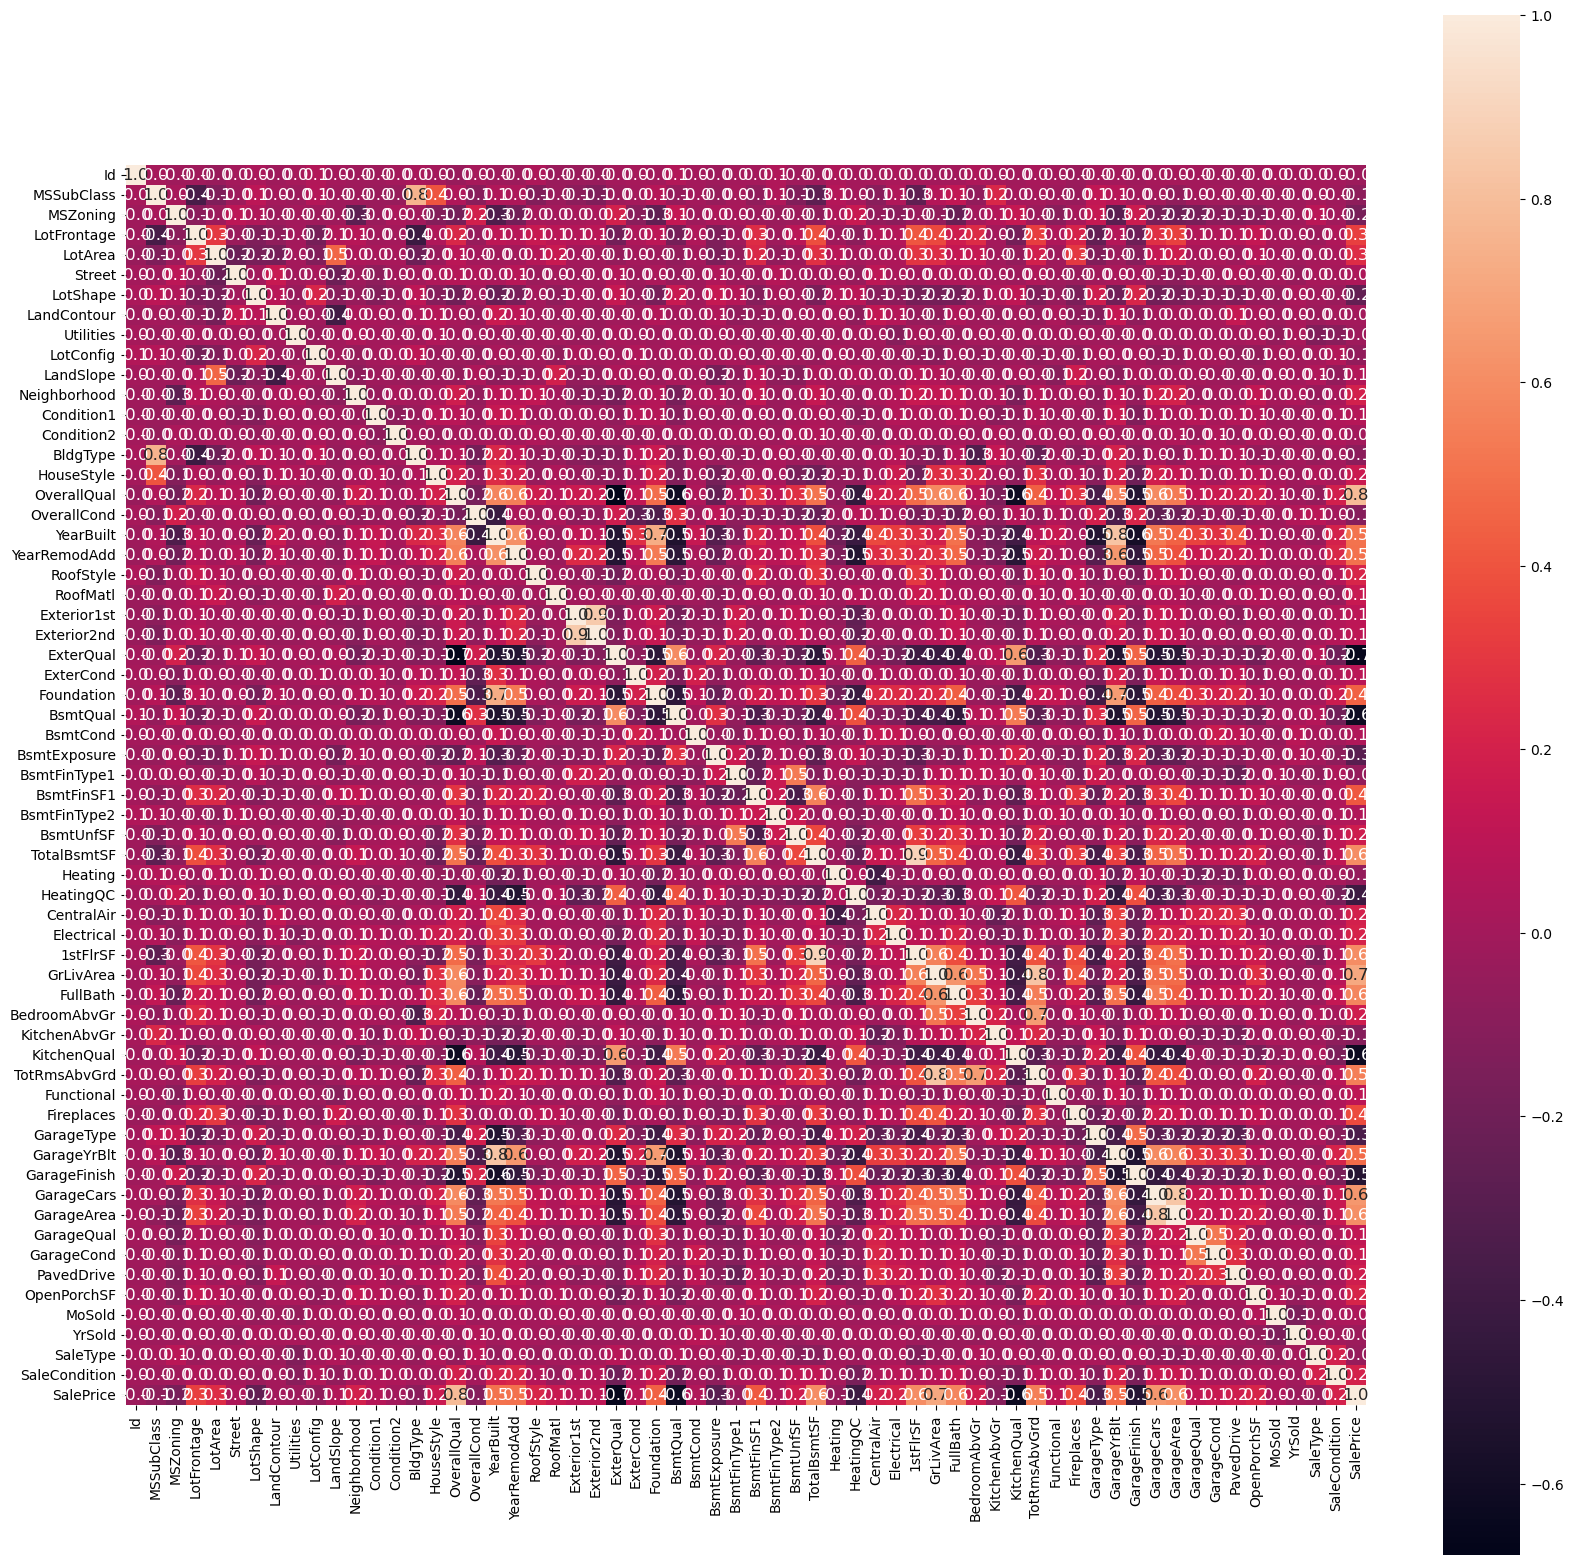

In [27]:
plt.figure(figsize = (20,20))
sns.heatmap(correlation, square = True, fmt = '.1f', annot = True, annot_kws = {'size':12})

# Group 1

In [28]:
g1 = df.iloc[:, :20]
g1.shape

(1346, 20)

<Axes: >

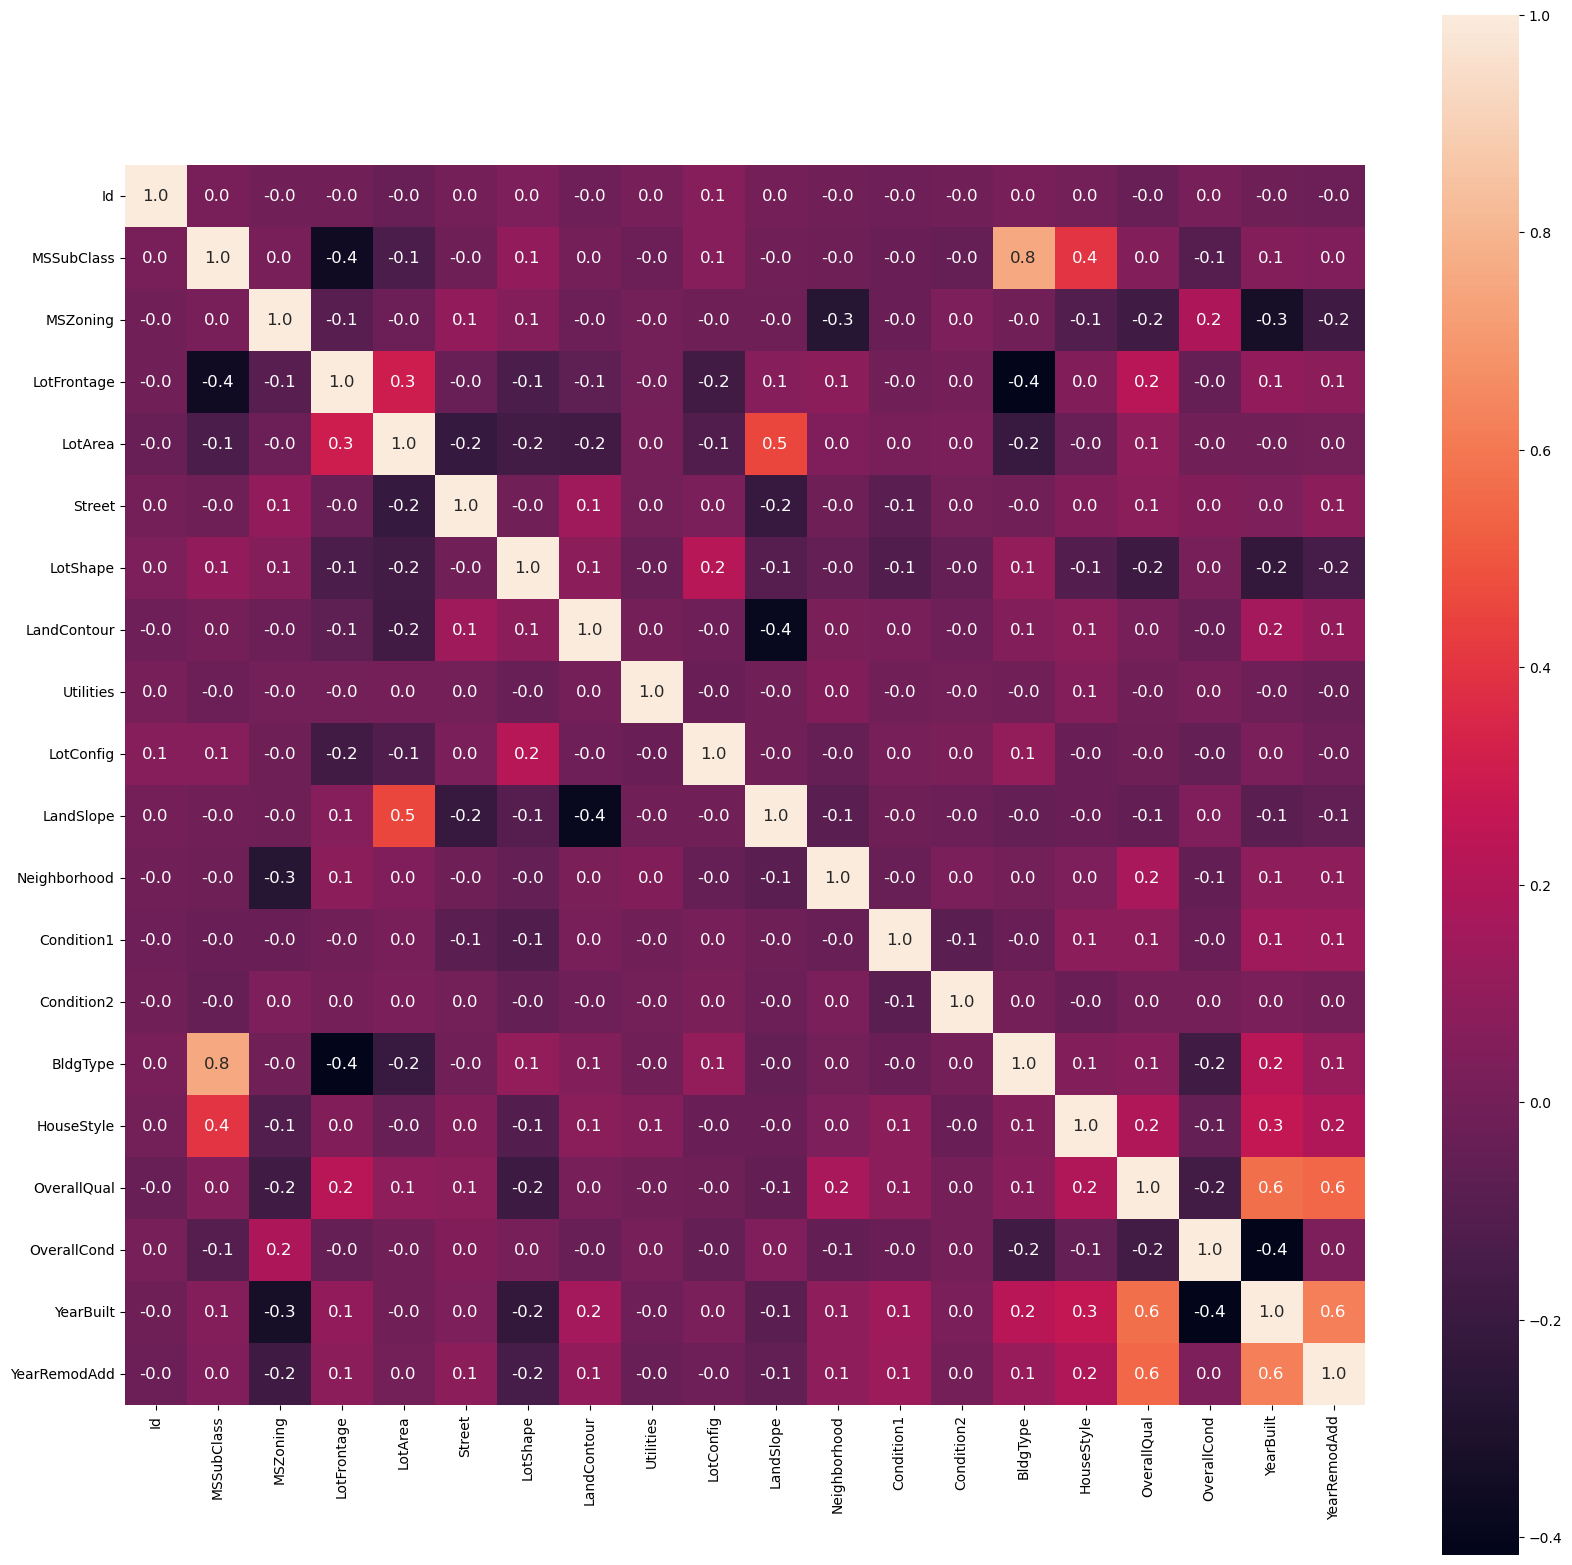

In [29]:
correlation = g1.corr()
plt.figure(figsize = (20,20))
sns.heatmap(correlation, square = True, fmt = '.1f', annot = True, annot_kws = {'size':12})

In [30]:
g1 = g1.drop(['Id', 'MSSubClass', 'Street', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'OverallCond' ], axis = 1)

In [31]:
df = df.drop(['Id', 'MSSubClass', 'Street', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'OverallCond' ], axis = 1)

In [32]:
for c in g1.columns:
    print(c, end = ' ' )
    

MSZoning LotFrontage LotArea LotShape LandContour BldgType HouseStyle OverallQual YearBuilt YearRemodAdd 

# 

# Group 2

In [33]:
g2 = df.iloc[:, 20:40]
g2.shape

(1346, 20)

<Axes: >

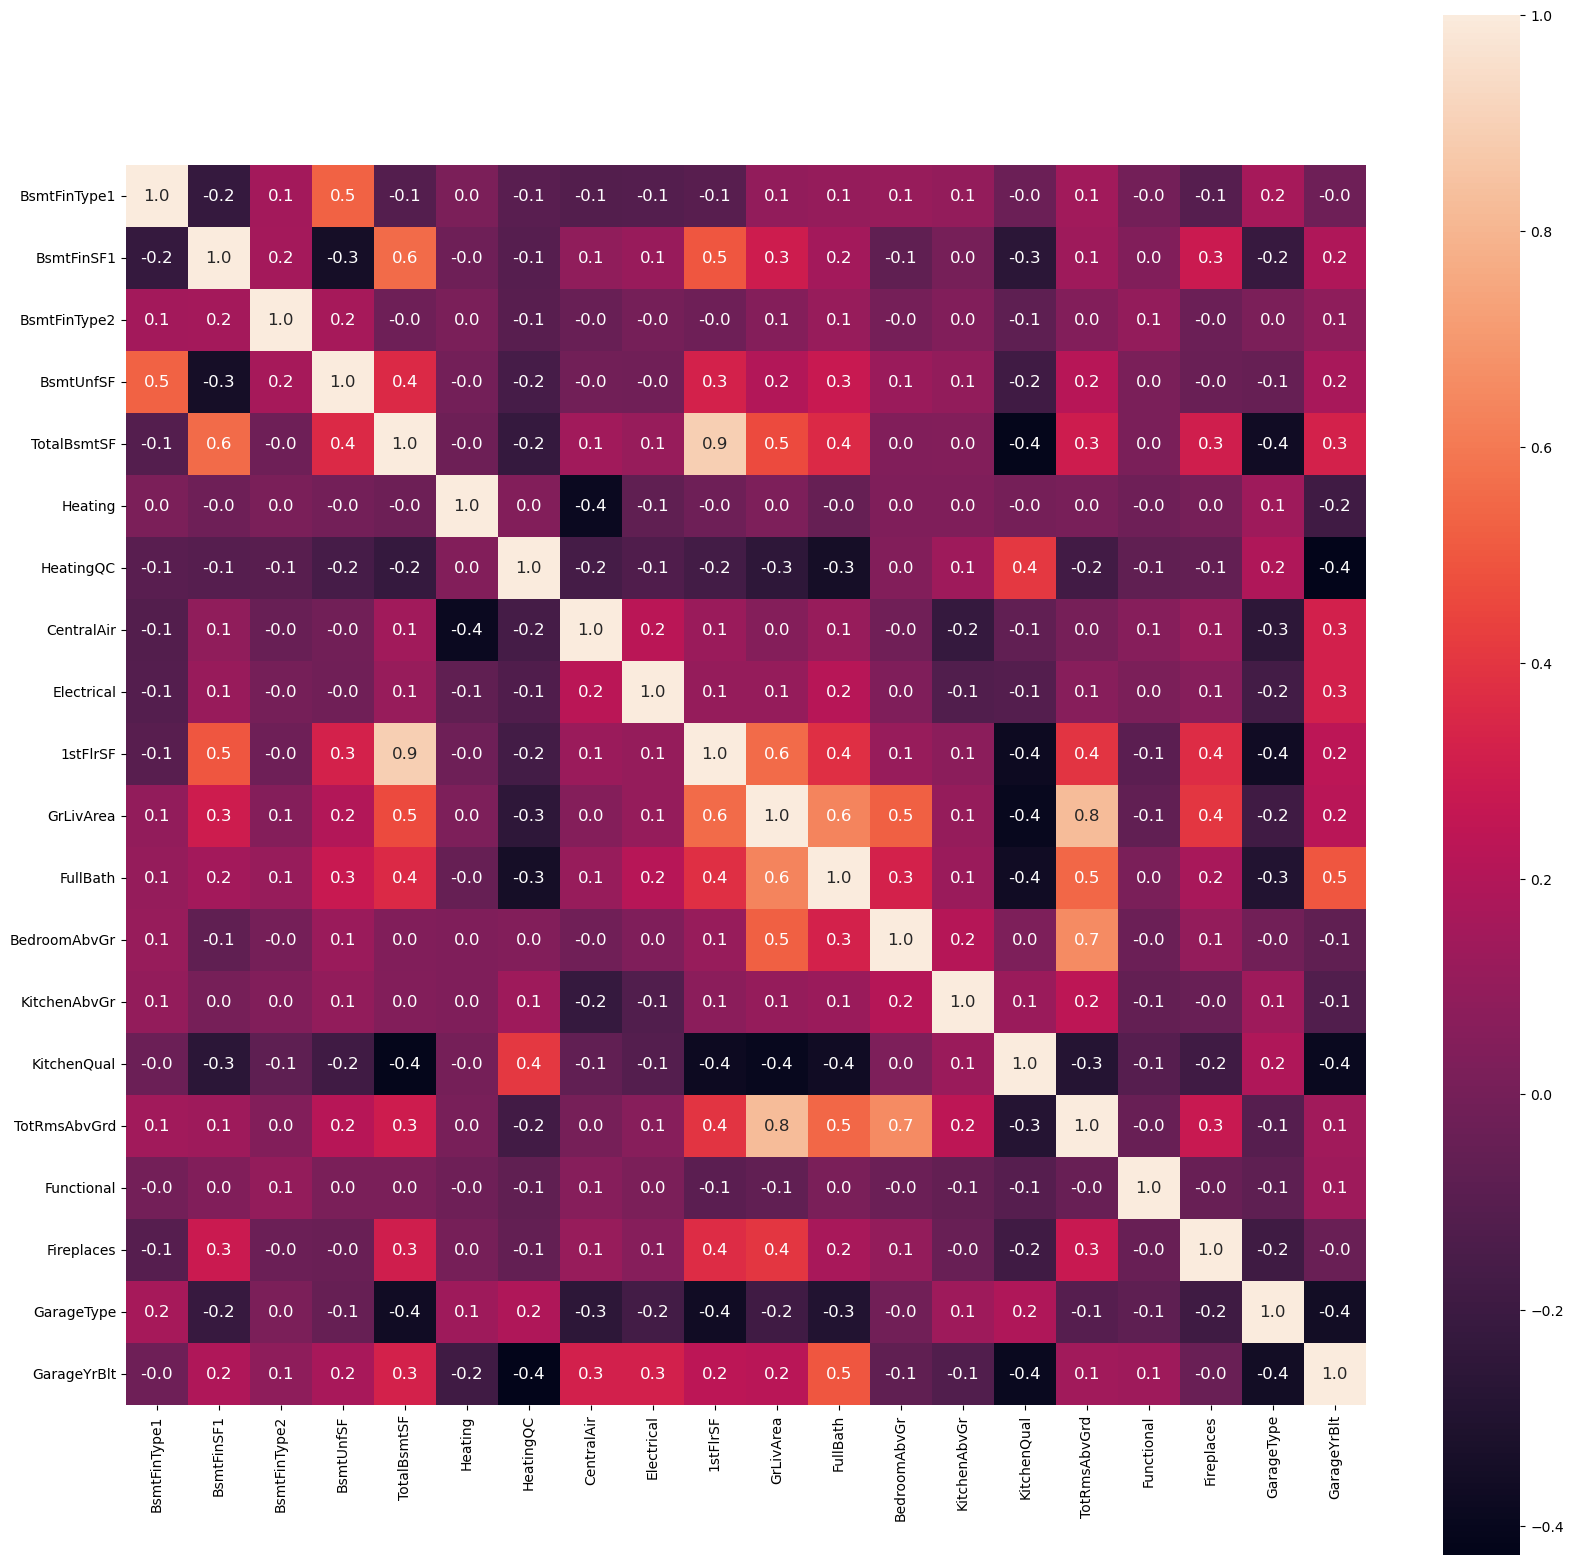

In [34]:
correlation = g2.corr()
plt.figure(figsize = (20,20))
sns.heatmap(correlation, square = True, fmt = '.1f', annot = True, annot_kws = {'size':12})

In [35]:
for c in g2.columns:
    print(c, end = ' ' )
    

BsmtFinType1 BsmtFinSF1 BsmtFinType2 BsmtUnfSF TotalBsmtSF Heating HeatingQC CentralAir Electrical 1stFlrSF GrLivArea FullBath BedroomAbvGr KitchenAbvGr KitchenQual TotRmsAbvGrd Functional Fireplaces GarageType GarageYrBlt 

In [36]:
g2 = g2.drop(['Heating'], axis = 1)

In [37]:
g2 = g2.drop(['BsmtFinType2'],axis=1)

In [38]:
df = df.drop(['Heating'], axis = 1)

In [39]:
df = df.drop(['BsmtFinType2'],axis=1)

# 

# Group 3

In [40]:
g3 = df.iloc[:, 40:]
g3.shape

(1346, 10)

<Axes: >

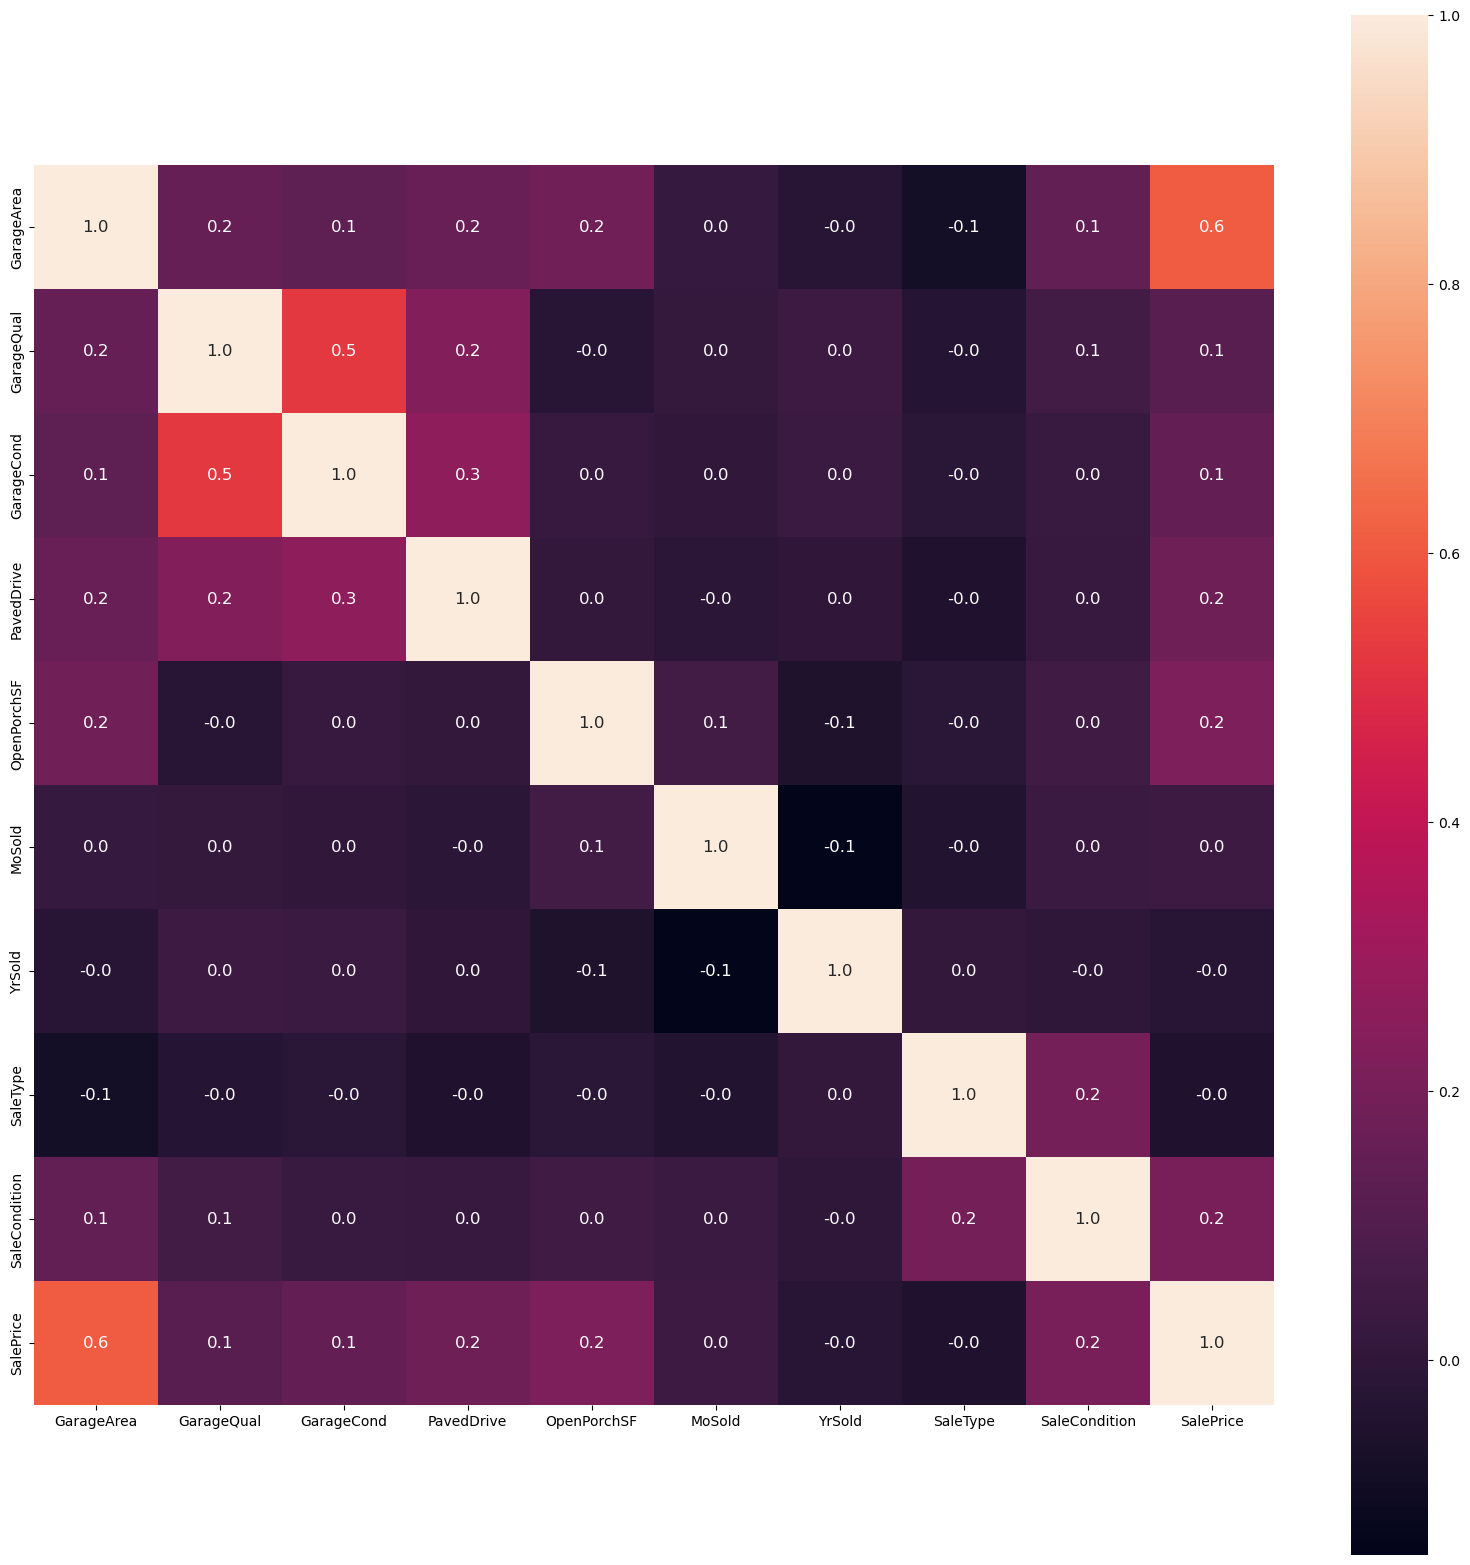

In [41]:
correlation = g3.corr()
plt.figure(figsize = (20,20))
sns.heatmap(correlation, square = True, fmt = '.1f', annot = True, annot_kws = {'size':12})

In [42]:
for c in g3.columns:
    print(c, end = ' ' )
    

GarageArea GarageQual GarageCond PavedDrive OpenPorchSF MoSold YrSold SaleType SaleCondition SalePrice 

In [43]:
g3 = g3.drop(['MoSold', 'YrSold', 'SaleType'], axis = 1)

In [44]:
g3 = g3.drop(['OpenPorchSF'], axis = 1)

In [45]:
df = df.drop(['MoSold', 'YrSold', 'SaleType'], axis = 1)

In [46]:
df = df.drop(['OpenPorchSF'], axis = 1)

In [47]:
df.shape

(1346, 46)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1346 entries, 0 to 1459
Data columns (total 46 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1346 non-null   int64  
 1   LotFrontage    1346 non-null   float64
 2   LotArea        1346 non-null   int64  
 3   LotShape       1346 non-null   int64  
 4   LandContour    1346 non-null   int64  
 5   BldgType       1346 non-null   int64  
 6   HouseStyle     1346 non-null   int64  
 7   OverallQual    1346 non-null   int64  
 8   YearBuilt      1346 non-null   int64  
 9   YearRemodAdd   1346 non-null   int64  
 10  RoofStyle      1346 non-null   int64  
 11  RoofMatl       1346 non-null   int64  
 12  Exterior1st    1346 non-null   int64  
 13  Exterior2nd    1346 non-null   int64  
 14  ExterQual      1346 non-null   int64  
 15  ExterCond      1346 non-null   int64  
 16  Foundation     1346 non-null   int64  
 17  BsmtQual       1346 non-null   int64  
 18  BsmtCond     

# Data Splitting

In [49]:
X = df.drop('SalePrice', axis = 1)
Y = df['SalePrice']

In [50]:
X.shape

(1346, 45)

In [51]:
Y.shape

(1346,)

In [142]:
from sklearn.model_selection import train_test_split
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(X,Y,  test_size = 0.30, random_state = 8)
print('Size of train X:', len(X_TRAIN))
print('Size of train Y:', len(Y_TRAIN))
print('Size of test X:', len(X_TEST))
print('Size of test Y:', len(Y_TEST))

Size of train X: 942
Size of train Y: 942
Size of test X: 404
Size of test Y: 404


# Linear Regression

In [143]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_TRAIN,Y_TRAIN)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [144]:
training_data_prediction = model.predict(X_TRAIN)
print(len(training_data_prediction))

942


In [145]:
# Libraries to check accuracy of the predicted answers
from sklearn import metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [146]:
score1 = metrics.r2_score(Y_TRAIN,training_data_prediction)
score2 = metrics.mean_absolute_error(Y_TRAIN,training_data_prediction)

print("R squared : ",score1)
print("Mean Absolute error : ",score2)

R squared :  0.8135037431667064
Mean Absolute error :  21005.96807979081


In [147]:
score3 = metrics.mean_squared_error(Y_TRAIN,training_data_prediction)
print("Mean squared error : ",score3)

Mean squared error :  1184354281.0564628


In [148]:
test_data_prediction = model.predict(X_TEST)

In [149]:
score1 = metrics.r2_score(Y_TEST,test_data_prediction)

In [150]:
print("R squared : ",score1)

R squared :  0.8565624866581241
